# Armillary tutorial

Armillary makes a coordinate system for a set of stellar spectra from the spectra alone. It then transfers labels from a few labelled stars to all the other stars through these coordinates. The labels can be effective temperature, surface gravity, metallicity, or other measured quantities.

This notebook applies the method to a grid of synthetic spectra. The true labels of these spectra are known, thus you can compare each step with the truth. The notebook has these parts:

1. The example spectra.
2. The showcase of the paper (Ting & Saad 2026): the coordinates recover the label grid without labels.
3. The method, step by step.
4. The transfer of labels from a few stars to all the other stars.
5. Noise, and the error-weighted distance.
6. How to use the same calls on your own spectra.

The method has five steps. The table gives the module of each step:

| step | what it does | module |
| --- | --- | --- |
| 1 | Divide each spectrum by a local continuum. Then get the distance between two spectra from their cumulative absorption in chunks of different widths. | `preprocess`, `distance` |
| 2 | Join each star to its nearest neighbours under the distance, in one connected graph. Then measure the geodesic distances along the graph. | `lattice` |
| 3 | Change the geodesic distances into coordinates (landmark multidimensional scaling). | `coordinates` |
| 4 | Make each star agree with the weighted sum of its neighbours, and keep the coordinates near those of step 3. | `refine` |
| 5 | Transfer the labels from a few labelled stars to all the other stars, through the same weights. | `labels` |

`armillary.fit` does steps 1 to 4 and returns a `Fit`. `Fit.propagate` does step 5.

In [1]:
import sys, numpy as np, matplotlib.pyplot as plt
import armillary as ar
from armillary import evaluate as ev
sys.path.insert(0, "examples"); import tutorial_figures as tf      # the figures of the tutorial
print("armillary", ar.__version__)

armillary 0.3.0


## 1. The example spectra

`examples/synthetic_spectra.npz` holds a grid of 4,675 synthetic spectra from 480 to 680 nm, at a resolving power of 10,000. [Payne-Zero](https://github.com/tingyuansen/payne-zero) calculated the spectra, and they are continuum-normalised. The paper uses the same grid at a resolving power of 20,000. The grid has all the combinations of these labels:

- effective temperature from 4000 to 7000 K, in steps of 125 K
- surface gravity from 1 to 5, in steps of 0.25
- metallicity from −2 to +0.5, in steps of 0.25

Each spectrum has its true labels.

Synthetic stellar spectra for the Armillary tutorial: Payne Zero one-dimensional LTE synthesis, 480 to 680 nm, degraded to a resolving power of 10,000 and sampled at 2.5 pixels per resolution element, continuum-normalised. A grid of 4,675 spectra: Teff 4000-7000 K in steps of 125 K x log g 1-5 in steps of 0.25 x [Fe/H] -2 to +0.5 in steps of 0.25, all with [alpha/M] = 0 and 1.5 km/s microturbulence. Arrays: flux [N, P] float16 (precision 5e-4; cast to float32 to use), wavelength_nm [P] float64, labels [N, 3] float32 (Teff, log g, [Fe/H]).
(4675, 8702) spectra x pixels


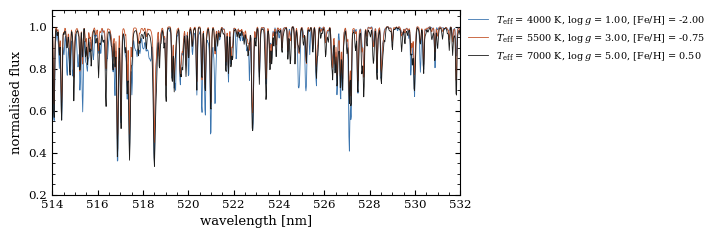

In [2]:
z = np.load("examples/synthetic_spectra.npz")
flux = z["flux"].astype(np.float32); wl = z["wavelength_nm"]; labels = z["labels"].astype(float)
print(str(z["readme"]))
print(flux.shape, "spectra x pixels")

fig, ax = plt.subplots(figsize=(tf.fs.FULL_WIDTH, 2.4))
for i, c in zip([0, 2337, 4674], [tf.fs.BLUE, tf.fs.ORANGE, tf.fs.INK]):
    ax.plot(wl, flux[i], lw=0.6, color=c, label=rf"$T_{{\rm eff}}$ = {labels[i,0]:.0f} K, $\log g$ = {labels[i,1]:.2f}, [Fe/H] = {labels[i,2]:.2f}")
ax.set_xlim(514, 532); ax.set_ylim(0.2, 1.08); ax.set_xlabel("wavelength [nm]"); ax.set_ylabel("normalised flux")
ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0); fig.subplots_adjust(right=0.7); plt.show()

## 2. The showcase: a label grid from the spectra alone

Apply the method to the grid. `fit` uses three inputs: the flux, a boolean mask of the good pixels, and the detector segment of each pixel. Here there is one segment.

The settings are those of the synthetic grid in the paper: one chunking of 32 chunks, three coordinates, and 50 neighbours for the refinement. All the other fields keep their defaults. At this size, the exact neighbour search is fast. For a sample of hundreds of thousands of stars, use `search="nndescent"`. The fit takes less than one minute.

In [3]:
settings = dict(chunkings=((32,),), d=3, k_refine=50)      # one chunking of 32 chunks, three coordinates, 50 neighbours
F = ar.fit(flux, np.ones(flux.shape, bool), np.zeros(flux.shape[1], int), ar.Config(**settings))
print("eigenvalue ratios:", np.round(F.eigenvalues[:8] / F.eigenvalues[0], 3))

[     0s] fit: 4675 spectra x 8702 pixels; search exact; threads 10


[     7s] normalised flux: 8702 pixels, 6.7 s


[     8s] features: 8702 columns from [32] chunks, medians over 124750 pairs of 500 stars, 0.9 s


[    27s] neighbours: k = 50 by exact search, 18.9 s
[    27s] lattice: k-NN graph has 1 component(s)
[    27s] lattice: 79020 edges, 33.8 per star, 1 component(s), 0 bridge(s)


[    32s] geodesics: Dijkstra from 4675 landmark(s), 5.9 s


[    66s] coordinates: d = 3; eigenvalue ratios [1.0, 0.497, 0.08, 0.023, 0.021, 0.015, 0.011, 0.009], 33.2 s


[    67s] refinement weights on the 30-component projection (1.1 s), k = 50 neighbours under D (0.3 s)


[    67s] refined: rho = 0.003, max relative residual 9.5e-09, 0.3 s
[    67s] done in 67 s
eigenvalue ratios: [1.    0.497 0.08  0.023 0.021 0.015 0.011 0.009]


The grid has three labels, and its three largest eigenvalues are much larger than the others. The eigenvalues help you select the number of coordinates. On a curved manifold, this number is not always equal to the number of physical labels.

Now plot the stars at three metallicities. The top row is the label grid of the synthesis. Each star is at its (Teff, log g), and the grid lines join adjacent grid points. The bottom row shows the same stars in the first two recovered coordinates, with the same grid lines. The bottom row uses no labels. The coordinates are a smooth distortion of the label plane: at each metallicity, temperature goes in one direction and gravity goes in the other direction.

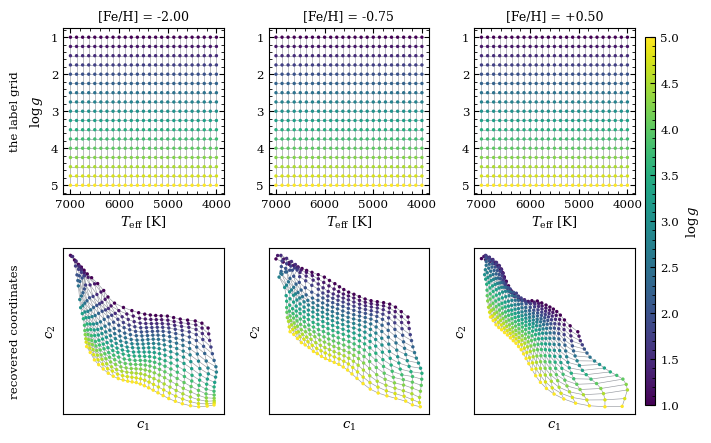

In [4]:
fig = tf.lattice(F.C, labels, feh_values=[-2.0, -0.75, 0.5]); plt.show()

## 3. The method, step by step

The figure below (Figure 1 of the paper) shows the steps of `fit` and `propagate` on a two-dimensional manifold:

1. **distance**: two spectra and, below them, their cumulative absorption curves in one wavelength chunk. The shaded area between the curves is their distance in that chunk. The distance between the spectra is the sum over the chunks of all the chunkings.
2. **all pairs**: the table of the distances between all the pairs of stars.
3. **graph**: each star joined to its nearest neighbours under the distance, on the manifold of the spectra.
4. **geodesic**: the shortest path through the graph between two distant stars. This distance goes *along* the manifold, not across a fold.
5. **coordinates**: the geodesic distances, changed into coordinates by landmark multidimensional scaling. The graph adds small errors, thus the lines of constant parameters through the recovered positions are not smooth.
6. **refinement**: the same coordinates after the locally linear refinement. The refinement decreases the small errors and keeps the coordinates near those of step 5.
7. **labels**: the labels of four stars (the orange stars), transferred to all the other stars through the same weights.

The `Fit` from `fit` keeps all these products. `F.features` holds step 1, `F.nbr` and `F.dist` hold the neighbours and their distances, and `F.lattice` holds step 3. `F.landmarks`, `F.eigenvalues` and `F.C_geo` hold step 5, and `F.W` and `F.C` hold step 6. `F.propagate` does step 7.

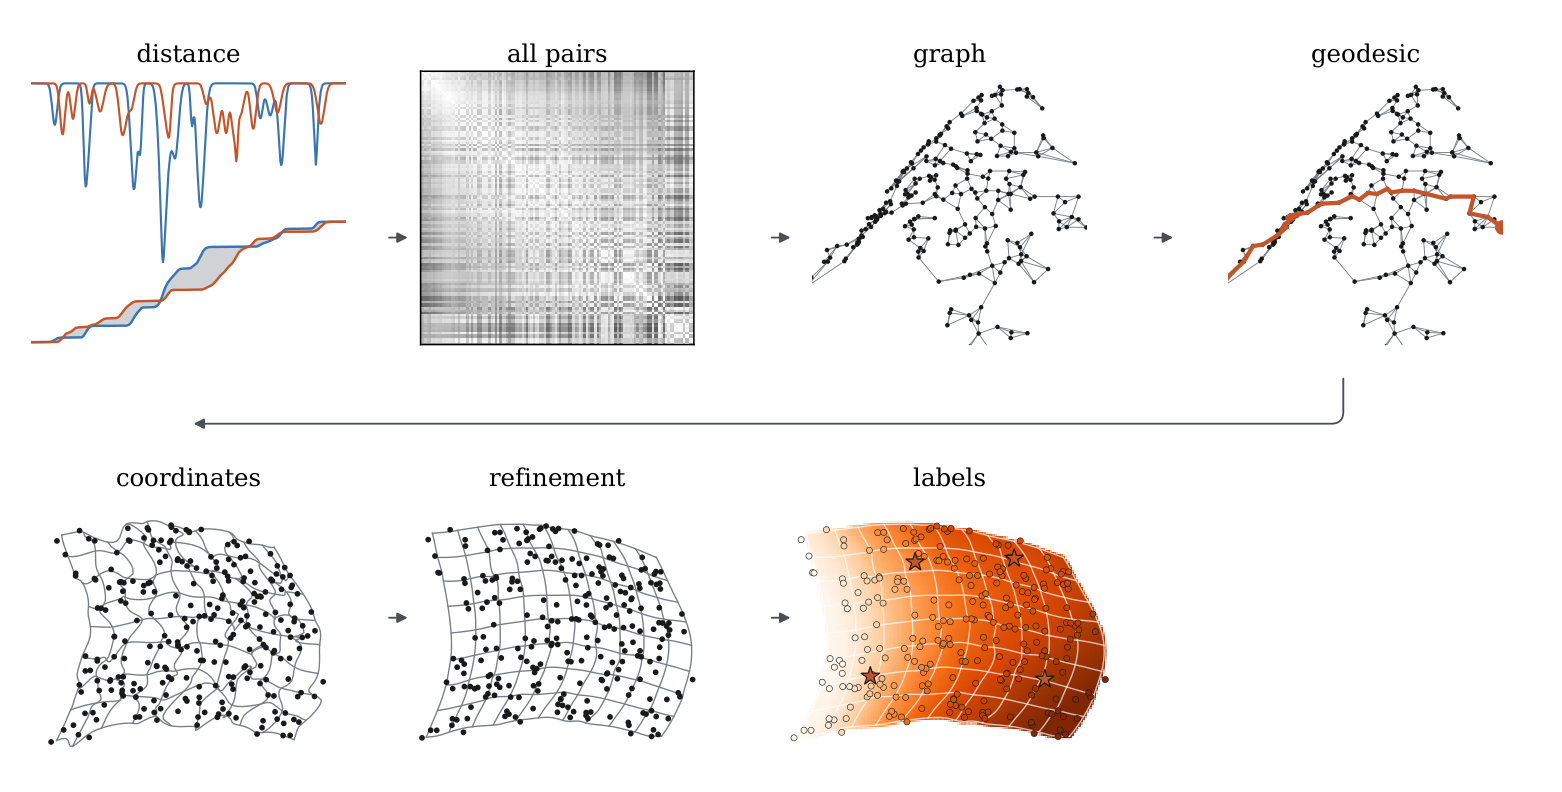

In [5]:
from IPython.display import Image
Image("examples/armillary_schematic.png", width=950)

## 4. Labels for all the stars from a few labelled stars

In this example, only 50 of the 4,675 stars have known labels. `Fit.propagate` uses the labels of these stars and gives labels to all the stars. The labels of each star must be the same weighted sum of the labels of its neighbours as its spectrum is of their spectra.

Here the 50 stars are a random selection. For your own spectra, use `ar.labels.density_draw(F.C, n)`. This function selects the stars as the paper does: the probability is proportional to the local density in the coordinates, to the power −1/4. Thus the sparse regions also get labelled stars.

The error statistic of the tutorial is `evaluate.error`. It is half the central 68 percent range of the differences, which is the width of a Gaussian with the same core. Thus the few stars that the graph puts in the wrong place do not set the value.

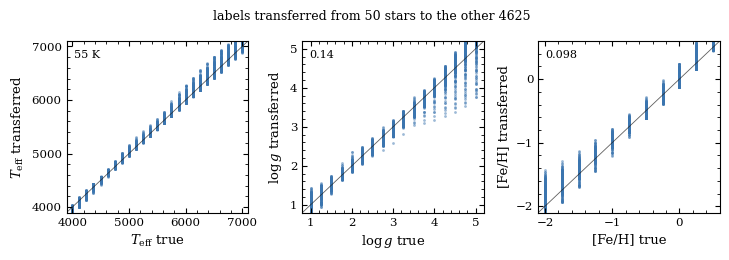

In [6]:
N = len(flux); rng = np.random.default_rng(1); labelled = rng.choice(N, 50, replace=False); held = np.setdiff1d(np.arange(N), labelled)
Y = F.propagate(labels, labelled_index=labelled)
fig = tf.one_to_one(labels[held], Y[held], title=f"labels transferred from 50 stars to the other {len(held)}"); plt.show()

## 5. Noise, and the error-weighted distance

Real spectra have noise. First, add Gaussian noise at a signal-to-noise ratio of 30 at each pixel, and do the fit again. The distance uses the cumulative absorption, which averages the noise in each chunk. Compare the errors below with the errors without noise.

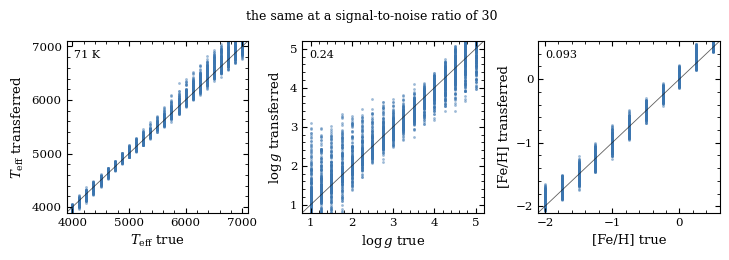

   Teff   noiseless 54.831   S/N 30 71.221
   log g  noiseless 0.135   S/N 30 0.245
   [Fe/H] noiseless 0.098   S/N 30 0.093


In [7]:
snr = 30.0
noisy = (flux + rng.normal(0, 1 / snr, flux.shape)).astype(np.float32)
Fn = ar.fit(noisy, np.ones(noisy.shape, bool), np.zeros(noisy.shape[1], int), ar.Config(**settings), log=None)
Yn = Fn.propagate(labels, labelled_index=labelled)
fig = tf.one_to_one(labels[held], Yn[held], title="the same at a signal-to-noise ratio of 30"); plt.show()
for name, e0, e1 in zip(["Teff", "log g", "[Fe/H]"], ev.error(Y[held] - labels[held]), ev.error(Yn[held] - labels[held])): print(f"   {name:6s} noiseless {e0:.3f}   S/N 30 {e1:.3f}")

In real spectra, the noise is not the same at all wavelengths. The signal-to-noise ratio decreases where the throughput decreases, and the pixels under sky lines have much more noise than the adjacent pixels. If the error array shows this structure, use `Config(error_weights=True)`. Then the inverse variance of each pixel multiplies its absorption in the cumulative curves. Thus the noisy pixels hold less of the absorption of a chunk.

Use the weights if the errors have a structure of their own, for example from the sky and the detector. The default is `False`, because the weights make the results worse if the errors follow the photon noise. In that case, the weights move absorption into the strong lines, and the brightness of the star goes into the distance.

In this example, the signal-to-noise ratio decreases from 60 at the blue end to 20 at the red end. Also, 5 percent of the pixels are under sky lines, with four times the noise. `fit` gets `err`, and the two runs are different only in `error_weights`.

In [8]:
sigma = (1 / 60.0) * (1 + 2.0 * (wl - wl[0]) / (wl[-1] - wl[0]))           # S/N 60 at the blue end, 20 at the red end
sky = np.random.default_rng(2).random(flux.shape[1]) < 0.05; sigma = np.where(sky, 4 * sigma, sigma)   # sky lines
err = np.tile(sigma.astype(np.float32), (flux.shape[0], 1)); structured = (flux + np.random.default_rng(3).normal(size=flux.shape) * err).astype(np.float32)
errors = {}
for weighted in (False, True):
    Fw = ar.fit(structured, np.ones(flux.shape, bool), np.zeros(flux.shape[1], int), ar.Config(**settings, error_weights=weighted), err=err, log=None)
    errors[weighted] = ev.error(Fw.propagate(labels, labelled_index=labelled)[held] - labels[held])
for name, e0, e1 in zip(["Teff", "log g", "[Fe/H]"], errors[False], errors[True]): print(f"   {name:6s} unweighted {e0:.3f}   error-weighted {e1:.3f}")

   Teff   unweighted 133.851   error-weighted 122.808
   log g  unweighted 0.508   error-weighted 0.473
   [Fe/H] unweighted 0.161   error-weighted 0.148


## 6. Your own spectra

The calls are the same for real spectra. Only the input and the configuration change.

- **Input.** `flux [N, P]` and `good [N, P]` (False on a bad pixel). `segments [P]` gives the detector segment of each pixel, from 0, so that no chunk crosses a gap. Give `err [N, P]` if the spectra keep their instrumental response (then use `Config(continuum="running")`), or if the errors have a structure of their own (then use `error_weights=True`).
- **Configuration.** The defaults of `Config()` are the values of the paper, with three chunkings of 10, 20 and 40 chunks on one segment. For several segments, give the number of chunks in each segment, for each chunking. For more than a few tens of thousands of stars, set `n_landmarks=800` and `search="nndescent"`. `armillary/pipeline.py` describes each field, and `Config.save` and `Config.load` write and read a configuration as JSON.
- **Scale.** For 200,000 spectra, the full method takes less than one hour on one computer node. Most of the time is in the neighbour search. `Config.threads` sets the number of cores for numba.
- **Save.** `Fit.save(path)` writes the coordinates, the eigenvalues, the landmarks, the neighbour lists and the configuration to a compressed `.npz` file. To transfer more labels later, call `Fit.propagate` again on the same `Fit`.

In [9]:
cfg = ar.Config(n_landmarks=800, search="nndescent")       # the settings for a large sample
print({k: v for k, v in cfg.to_dict().items() if k in ("chunkings", "k_lattice", "n_landmarks", "d", "k_refine", "search", "mu")})
F.save("examples/output_grid_fit.npz")

{'chunkings': ((10,), (20,), (40,)), 'k_lattice': 30, 'search': 'nndescent', 'n_landmarks': 800, 'd': 4, 'k_refine': 100, 'mu': 3.0}
